# Feed-Forward Neural Network 

Predicts hospital **readmission** (`<30`, `>30`, `NO`) from the cleaned dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
)

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

## 1. Load Cleaned Dataset

In [14]:
DATA_PATH = "diabetes+130-us+hospitals+for+years+1999-2008/diabetic_data_cleaned.csv"

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")

Shape: (101766, 45)


## 2. Target Variable

Encode `readmitted` (`<30`, `>30`, `NO`) as integers with `LabelEncoder` — required by `MLPClassifier`.

In [ ]:
TARGET = "readmitted"

X = df.drop(columns=[TARGET])
y_raw = df[TARGET]

le = LabelEncoder()
y = le.fit_transform(y_raw)

print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print()
print("Class distribution:")
print(y_raw.value_counts())

Class mapping: {'<30': np.int64(0), '>30': np.int64(1), 'NO': np.int64(2)}

Class distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


## 3. Feature Types

In [4]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Numeric  ({len(numeric_features)}):     {numeric_features}")
print()
print(f"Categorical ({len(categorical_features)}): {categorical_features}")

Numeric  (11):     ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical (33): ['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


## 4. Preprocessing Pipeline

In [5]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline,     numeric_features),
    ("cat", categorical_pipeline, categorical_features)
], remainder="drop")

## 5. Train / Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")

Train: 81,412  |  Test: 20,354


## 6. Define the Neural Network

Architecture: **128 → 64** hidden units, ReLU, Adam, early stopping.

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-4,              
    learning_rate_init=1e-3,
    max_iter=200,
    early_stopping=True,     
    validation_fraction=0.10,
    n_iter_no_change=10,
    random_state=RANDOM_STATE,
    verbose=False
)

## 7. Build & Fit the Full Pipeline

In [8]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model",      mlp)
])

pipeline.fit(X_train, y_train)

print(f"Stopped after {pipeline['model'].n_iter_} iterations")

Stopped after 13 iterations


## 8. Evaluation

In [9]:
y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")

print(f"Accuracy : {acc:.4f}")
print(f"ROC-AUC  : {roc:.4f}  (weighted OvR)")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy : 0.5827
ROC-AUC  : 0.6704  (weighted OvR)

Classification Report:
              precision    recall  f1-score   support

         <30       0.46      0.01      0.02      2272
         >30       0.50      0.38      0.43      7109
          NO       0.62      0.83      0.71     10973

    accuracy                           0.58     20354
   macro avg       0.52      0.41      0.39     20354
weighted avg       0.56      0.58      0.53     20354



### 8a. Confusion Matrix

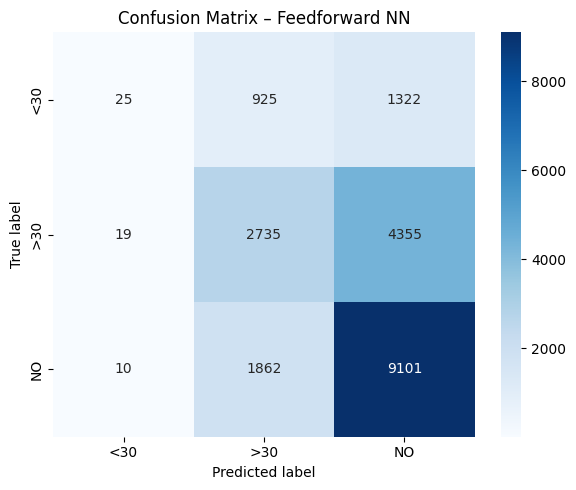

In [10]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix – Feedforward NN")
plt.tight_layout()
plt.show()

### 8b. Loss Curve

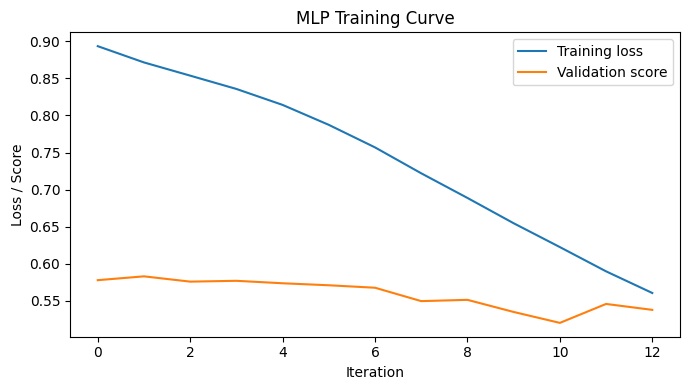

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(pipeline["model"].loss_curve_, label="Training loss")
ax.plot(pipeline["model"].validation_scores_, label="Validation score")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss / Score")
ax.set_title("MLP Training Curve")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Cross-Validation (5-fold)

Stratified CV on the training set for a more robust accuracy estimate.

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=1)

print(f"CV Accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(f"Per-fold:    {np.round(cv_scores, 4)}")

CV Accuracy: 0.5824 +/- 0.0027
Per-fold:    [0.5834 0.585  0.5852 0.5788 0.5795]
